# IceAnalytics

## 1- Carga y Exploración

In [113]:
import pandas as pd
import numpy as np

In [114]:
# El low memory evita warnings de tipos mixtos en columnas grandes
df_raw = pd.read_csv('product_activity.csv', low_memory=False)

In [115]:
# Vista rapida de los datos "crudos" y sus formatos 
print("=" * 70)
print("HEAD (primeras 5 filas)")
print("=" * 70)
print(df_raw.head())

HEAD (primeras 5 filas)
  user_id           created_at country plan_type  user_age   post_id  \
0  U01988  2025-02-18T02:07:44      PY       pro      26.0  P0008515   
1  U00236  2025-06-22T07:49:10      BR      free      27.0  P0001023   
2  U00791  2024-02-12T02:45:45      CL      free      28.0  P0003405   
3  U01522  2024-09-22T07:06:50      US      free      16.0  P0006524   
4  U01092  2025-07-18T02:27:52      PY      free       NaN  P0004665   

  post_category      post_created_at  votes_received  user_total_posts  \
0        sport   2025-05-07T20:55:28               7                16   
1          tech  2025-09-13T20:31:06               1                 9   
2          tech  2024-02-14T05:17:48              11                 2   
3       finance  2024-09-24T07:51:34               5                 2   
4     education  2025-07-24T04:56:56               7                 2   

   days_since_signup device_type  
0                 78      mobile  
1                 83        

In [116]:
print("\n" + "=" * 70)
print("INFO (tipos de dato y nulos por columna)")
print("=" * 70)

df_raw.info()


INFO (tipos de dato y nulos por columna)
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [117]:
# Estadistica descriptiva de columnas numericas
# include='all' tambien nos muestra resumen de columnas categóricas
print("\n" + "=" * 70)
print("DESCRIBE (numéricas)")
print("=" * 70)
print(df_raw.describe())


DESCRIBE (numéricas)
          user_age  votes_received  user_total_posts  days_since_signup
count  8028.000000     8782.000000       8782.000000        8782.000000
mean     27.902591        6.918356          8.324186          29.479390
std       7.547052        5.127311          6.754906          36.819928
min      16.000000        0.000000          1.000000           0.000000
25%      22.000000        3.000000          4.000000           5.000000
50%      28.000000        6.000000          6.000000          17.000000
75%      33.000000        9.000000         11.000000          40.000000
max      58.000000       74.000000         39.000000         404.000000


In [118]:
# Descripcion de todas las columnas
print("\n" + "=" * 70)
print("DESCRIBE (todas las columnas, incluye categóricas)")
print("=" * 70)
print(df_raw.describe(include='all'))


DESCRIBE (todas las columnas, incluye categóricas)
       user_id           created_at country plan_type     user_age   post_id  \
count     8782                 8782    8782      8782  8028.000000      8782   
unique    2010                 2010      10        19          NaN      8610   
top     U00087  2024-01-08T12:18:18      US      free          NaN  P0002865   
freq        40                   40    1928      5978          NaN         2   
mean       NaN                  NaN     NaN       NaN    27.902591       NaN   
std        NaN                  NaN     NaN       NaN     7.547052       NaN   
min        NaN                  NaN     NaN       NaN    16.000000       NaN   
25%        NaN                  NaN     NaN       NaN    22.000000       NaN   
50%        NaN                  NaN     NaN       NaN    28.000000       NaN   
75%        NaN                  NaN     NaN       NaN    33.000000       NaN   
max        NaN                  NaN     NaN       NaN    58.000000  

In [119]:
# Dimensiones del dataset: (filas, columnas)
print(f"\nShape del dataset RAW: {df_raw.shape}")
print(f"Total de filas (eventos/post): {df_raw.shape[0]}")
print(f"Total de columnas: {df_raw.shape[1]}")



Shape del dataset RAW: (8782, 12)
Total de filas (eventos/post): 8782
Total de columnas: 12


## 2- Data Quality Report - Diagnostico

In [120]:
# Nulos por columna
print("=" * 60)
print("NULOS POR COLUMNA")
print("=" * 60)

nulos = df_raw.isnull().sum()
nulos_pct = (df_raw.isnull().mean() * 100).round(2)
reporte_nulos = pd.DataFrame({'nulos': nulos, '%nulos': nulos_pct})

print(reporte_nulos[reporte_nulos['nulos'] > 0])

NULOS POR COLUMNA
          nulos  %nulos
user_age    754    8.59


In [121]:
# Duplicados
print("\n" + "=" * 60)
print("DUPLICADOS")
print("=" * 60)

duplicados_exactos = df_raw.duplicated().sum()

print(f"Filas 100% duplicadas (todas las columnas iguales): {duplicados_exactos}")

# Duplicados por post_id
dup_post_id = df_raw['post_id'].duplicated().sum()
print(f"post_id repetidos: {dup_post_id}")
    


DUPLICADOS
Filas 100% duplicadas (todas las columnas iguales): 172
post_id repetidos: 172


In [122]:
# Valores únicos y frecuencias de columnas categóricas "sucias"
print("\n" + "=" * 60)
print("PLAN_TYPE — valores únicos y frecuencias")
print("=" * 60)

print(df_raw['plan_type'].value_counts(dropna=False))
#---------------------------------------------------------------
print("\n" + "=" * 60)
print("POST_CATEGORY — valores únicos y frecuencias")
print("=" * 60)

print(df_raw['post_category'].value_counts(dropna=False))
#---------------------------------------------------------------
print("\n" + "=" * 60)
print("DEVICE_TYPE — valores únicos y frecuencias")
print("=" * 60)

print(df_raw['device_type'].value_counts(dropna=False))


PLAN_TYPE — valores únicos y frecuencias
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

POST_CATEGORY — valores únicos y frecuencias
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Spo

In [123]:
# Chequeos lógicos de fechas (AÚN COMO STRING)
_created_at_temp = pd.to_datetime(df_raw['created_at'], errors='coerce')
_post_created_at_temp = pd.to_datetime(df_raw['post_created_at'], errors='coerce')

no_parseables_signup = _created_at_temp.isna().sum()
no_parseables_post = _post_created_at_temp.isna().sum()

print("\n" + "=" * 70)
print("FECHAS NO PARSEABLES")
print("=" * 70)
print(f"created_at (signup) no parseables: {no_parseables_signup}")
print(f"post_created_at no parseables: {no_parseables_post}")

post_antes_signup = (_post_created_at_temp < _created_at_temp).sum()
print(f"\nPosts creados ANTES del signup del usuario: {post_antes_signup}")


FECHAS NO PARSEABLES
created_at (signup) no parseables: 1
post_created_at no parseables: 1

Posts creados ANTES del signup del usuario: 100


In [124]:
# Chequeo de la columna days_since_signup
dias_calculado_temp = (_post_created_at_temp - _created_at_temp).dt.days
mismatch_dias = (dias_calculado_temp != df_raw['days_since_signup']).sum()

print(f"\nFilas donde days_since_signup (original) NO coincide con el cálculo real: {mismatch_dias}")


Filas donde days_since_signup (original) NO coincide con el cálculo real: 4479


### 3- Normalización + Recálculo + Quarantine 

In [125]:
df = df_raw.copy()

# Normalizar columnas con strings
for col in ['plan_type', 'post_category', 'device_type']:
    df[col] = df[col].astype(str).str.strip().str.lower()
    
# Diccionario canonico
PLAN_CANONICO = {'free', 'pro', 'enterprise'}
DEVICE_CANONICO = {'web', 'mobile', 'desktop'}
CATEGORY_CANONICO = {'tech', 'life', 'sports', 'science', 'finance', 'gaming', 'music', 'health', 'education', 'travel'}

# Correccion de errores de tipeo en post_category
TYPO_MAP_CATEGORY = {
    'tehc'      :   'tech',
    'sciense'   :   'science',
    'gamming'   :   'gaming',
    'sporst'    :   'sports',
    'sp0rts'    :   'sports',
    'sport'     :   'sports',
    'finanse'   :   'finance',
    'educatoin' :   'education',
    'healt'     :   'health',
    'lfe'       :   'life',
    'musc'      :   'music',
    'trvael'    :   'travel'
}

df['post_category'] = df['post_category'].replace(TYPO_MAP_CATEGORY)

# Los que no se encuentran en el diccionario(Quarantine)
flag_plan_invalido = ~df['plan_type'].isin(PLAN_CANONICO)
flag_device_invalido = ~df['device_type'].isin(DEVICE_CANONICO)
flag_category_invalida = ~df['post_category'].isin(CATEGORY_CANONICO)

print(f"plan_type fuera del diccionario: {flag_plan_invalido.sum()} ({df.loc[flag_plan_invalido, 'plan_type'].unique()})")
print(f"device_type fuera del diccionario: {flag_device_invalido.sum()} ({df.loc[flag_device_invalido, 'device_type'].unique()})")
print(f"post_category fuera del diccionario: {flag_category_invalida.sum()} ({df.loc[flag_category_invalida, 'post_category'].unique()})")


plan_type fuera del diccionario: 3 (<StringArray>
['premium', 'vip', 'enterprise+']
Length: 3, dtype: str)
device_type fuera del diccionario: 3 (<StringArray>
['tablet', 'console', 'phone']
Length: 3, dtype: str)
post_category fuera del diccionario: 2 (<StringArray>
['politics', 'mistery']
Length: 2, dtype: str)


In [126]:
# Parseo de fechas a datatime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['post_created_at'] = pd.to_datetime(df['post_created_at'], errors='coerce')

flag_fecha_no_parseable = df['created_at'].isna() | df['post_created_at'].isna()

# Recalculo de 'days_since_signup'
df['days_since_signup_calc'] = (df['post_created_at'] - df['created_at']).dt.days

flag_post_antes_signup = df['days_since_signup_calc'] < 0

# Duplicados exactos
flag_duplicado = df.duplicated(keep='first')

# Construccion del reason_code
def construir_reason_code(row_idx):
    razones = []
    if flag_duplicado[row_idx]:
        razones.append('duplicated_row')
    if flag_fecha_no_parseable[row_idx]:
        razones.append('unparseable_date')
    if flag_post_antes_signup[row_idx]:
        razones.append('post_before_signup')
    if flag_plan_invalido[row_idx]:
        razones.append('invalid_plan_type')
    if flag_device_invalido[row_idx]:
        razones.append('invalid_device_type')
    if flag_category_invalida[row_idx]:
        razones.append('invalid_category')
    
    return '|'.join(razones)

mask_quarantine = (flag_duplicado | flag_fecha_no_parseable | flag_post_antes_signup | flag_plan_invalido | flag_device_invalido | flag_category_invalida)

df['reason_code'] = ''
df.loc[mask_quarantine, 'reason_code'] = [ construir_reason_code(i) for i in df.index[mask_quarantine]]

In [127]:
# CORE vs QUARANTINE
df_quarantine = df[mask_quarantine].copy()
df_core = df[~mask_quarantine].copy().drop(columns=['reason_code'])

print("\n" + "=" * 70)
print("RESUMEN DEL SPLIT")
print("=" * 60)

print(f"RAW total:        {len(df)}")
print(f"CORE (limpio):    {len(df_core)}")
print(f"QUARANTINE:       {len(df_quarantine)}")
print(f"% Quarantine:     {len(df_quarantine)/len(df)*100:.2f}%")

print("\nDesglose de reason_code en Quarantine:")
print(df_quarantine['reason_code'].value_counts())


RESUMEN DEL SPLIT
RAW total:        8782
CORE (limpio):    8507
QUARANTINE:       275
% Quarantine:     3.13%

Desglose de reason_code en Quarantine:
reason_code
duplicated_row                                            167
post_before_signup                                         95
duplicated_row|post_before_signup                           5
unparseable_date                                            2
invalid_plan_type                                           2
invalid_device_type                                         2
invalid_category                                            1
invalid_plan_type|invalid_device_type|invalid_category      1
Name: count, dtype: int64


## 4- Data Quality Report(resumen final)

In [128]:
dqr = {
    'filas_raw'                     : len(df_raw),
    'filas_core'                    : len(df_core),
    'filas_quarantine'              : len(df_quarantine),
    'pct_quarantine'                : round(len(df_quarantine) / len(df_raw) * 100, 2),
    'duplicados_removidos'          : int(flag_duplicado.sum()),
    'fechas_no_parseables'          : int(flag_fecha_no_parseable.sum()),
    'post_antes_signup'             : int(flag_post_antes_signup.sum()),
    'mismatch_days_since_signup'    : int(mismatch_dias),
    'pct_mismatch_dias'             : round(mismatch_dias / len(df_raw) * 100, 2)
}

for k, v in dqr.items():
    print(f"{k}: {v}")

filas_raw: 8782
filas_core: 8507
filas_quarantine: 275
pct_quarantine: 3.13
duplicados_removidos: 172
fechas_no_parseables: 2
post_antes_signup: 100
mismatch_days_since_signup: 4479
pct_mismatch_dias: 51.0


In [129]:
# Distribuciones de Volumen
print("Usuarios únicos por plan")

usuarios_por_plan = df_core.drop_duplicates('user_id').groupby('plan_type')['user_id'].count()
print(usuarios_por_plan)

print("--- Actividad (#posts) por país ---")
print(df_core.groupby('country')['post_id'].count().sort_values(ascending=False))

print("--- Actividad (#posts) por categoría ---")
print(df_core['post_category'].value_counts())

print("--- Actividad (#posts) por dispositivo ---")
print(df_core['device_type'].value_counts())


Usuarios únicos por plan
plan_type
enterprise      82
free          1545
pro            367
Name: user_id, dtype: int64
--- Actividad (#posts) por país ---
country
US    1873
BR    1600
AR    1168
PY     837
MX     802
CL     552
ES     546
CO     488
PE     393
UY     248
Name: post_id, dtype: int64
--- Actividad (#posts) por categoría ---
post_category
tech         1381
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        492
Name: count, dtype: int64
--- Actividad (#posts) por dispositivo ---
device_type
web        4270
mobile     3656
desktop     581
Name: count, dtype: int64


In [130]:
# Engagement - Votos
print("--- Votos por plan: media, mediana, percentiles ---")
engagement_por_plan = df_core.groupby('plan_type')['votes_received'].agg(
    media='mean',
    mediana='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    std='std',
    n='count'
)

print(engagement_por_plan)

print("\n--- Votos por categoria ---")
print(df_core.groupby('post_category')['votes_received'].agg(['mean', 'median', 'count']))

print("\n--- Votos por dispositivo ---")
print(df_core.groupby('device_type')['votes_received'].agg(['mean', 'median', 'count']))

print("\n--- Votos por país ---")
print(df_core.groupby('country')['votes_received'].agg(['mean','median','count']))

--- Votos por plan: media, mediana, percentiles ---
               media  mediana  p25   p75       std     n
plan_type                                               
enterprise  7.570571      7.0  4.0  10.0  4.897624   333
free        6.692706      6.0  3.0   9.0  5.029064  6567
pro         7.654014      7.0  4.0  10.0  5.490376  1607

--- Votos por categoria ---
                   mean  median  count
post_category                         
education      6.791483     6.0    681
finance        6.978898     6.0    853
gaming         7.186074     6.0    833
health         6.456166     6.0    673
life           6.173114     5.0   1034
music          6.286776     5.0    673
science        7.544828     6.0    870
sports         6.573255     6.0   1017
tech           7.687183     7.0   1381
travel         6.878049     6.0    492

--- Votos por dispositivo ---
                 mean  median  count
device_type                         
desktop      7.032702     6.0    581
mobile       6.828228   

In [131]:
# Evento vs Usuario
votos_promedio_evento = df_core['votes_received'].mean()

votos_promedio_por_usuario_individual = df_core.groupby('user_id')['votes_received'].mean()
votos_promedio_usuario = votos_promedio_por_usuario_individual.mean()

print(f"Promedio de votos POR EVENTO (post): {votos_promedio_evento:.2f}")
print(f"Promedio de votos POR USUARIO (agrupado): {votos_promedio_usuario:.2f}")
print(f"Diferencia: {votos_promedio_evento - votos_promedio_usuario:.2f}")

# Promedio de post por usuario
post_por_usuario = df_core.groupby('user_id')['post_id'].count()
print(f"\nPosts por usuario -> media {post_por_usuario.mean():.2f}, mediana: {post_por_usuario.median():.1f}, max: {post_por_usuario.max()}")

Promedio de votos POR EVENTO (post): 6.91
Promedio de votos POR USUARIO (agrupado): 6.90
Diferencia: 0.01

Posts por usuario -> media 4.27, mediana: 3.0, max: 39


**Interpretación — Por qué difieren evento vs usuario:**

El promedio por evento (6.91) y el promedio por usuario agrupado (6.90) son casi idénticos
en este dataset (diferencia de 0.01). Esto indica que, en este caso, no hay una fuerte
correlación entre volumen de posteo y nivel de votos — los usuarios muy activos no
"arrastran" el promedio hacia arriba ni hacia abajo de forma significativa.

En general, estos dos promedios *pueden* diferir bastante cuando hay usuarios con pocos
posts pero votos extremos (outliers), porque el promedio por evento les da a esos posts
el mismo peso que a cualquier otro, mientras que el promedio por usuario primero calcula
el promedio individual y luego promedia esos promedios, dándole a cada *usuario* el mismo
peso sin importar cuántos posts tenga. La similitud acá sugiere que la distribución de
votos está relativamente equilibrada entre usuarios activos e inactivos.

In [132]:
# Concentración - Regla de Pareto (Top 1%)

# Paso 1: Agregar actividad y votos totales POR USUARIO
actividad_usuario = df_core.groupby('user_id').agg(
    total_posts=('post_id', 'count'),
    total_votos=('votes_received', 'sum')
).reset_index()

n_usuarios = len(actividad_usuario)
top_1_pct_n = max(1, int(np.ceil(n_usuarios * 0.01)))

print(f"Total de usuarios únicos: {n_usuarios}")
print(f"Usuarios en el top 1%: {top_1_pct_n}")

# Paso 2: % de POSTS que viene del top 1% de usuarios (por volumne de posts)
top_posts = actividad_usuario.sort_values('total_posts', ascending=False).head(top_1_pct_n)
pct_posts_top1 = top_posts['total_posts'].sum() / actividad_usuario['total_posts'].sum() * 100
print(f"\n% de POST que genera el top 1% de usuarios (por actividad) : {pct_posts_top1:.2f}%")

# Paso 3: % de VOTOS que viene del top 1% de usuarios (por votos totales recibidos)
top_votos = actividad_usuario.sort_values('total_votos', ascending=False).head(top_1_pct_n)
pct_votos_top1 = top_votos['total_votos'].sum() / actividad_usuario['total_votos'].sum() * 100
print(f"% de VOTOS que concentra el top 1% de usuarios (por engagement): {pct_votos_top1:.2f}%")

# Bonus: Curva de concentracion completa (Top 1%, 5%, 10%, 20%)
actividad_usuario_sorted = actividad_usuario.sort_values('total_votos', ascending=False)
total_votos_global = actividad_usuario_sorted['total_votos'].sum()

print()

for pct in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(np.ceil(n_usuarios * pct)))
    votos_acumulados = actividad_usuario_sorted.head(n)['total_votos'].sum()
    print(f"Top {int(pct*100):>2}% de usuarios ({n:>4} usuarios) concentra el {votos_acumulados/total_votos_global*100:.2f}% de los votos totales")

Total de usuarios únicos: 1994
Usuarios en el top 1%: 20

% de POST que genera el top 1% de usuarios (por actividad) : 6.03%
% de VOTOS que concentra el top 1% de usuarios (por engagement): 6.43%

Top  1% de usuarios (  20 usuarios) concentra el 6.43% de los votos totales
Top  5% de usuarios ( 100 usuarios) concentra el 21.19% de los votos totales
Top 10% de usuarios ( 200 usuarios) concentra el 33.94% de los votos totales
Top 20% de usuarios ( 399 usuarios) concentra el 51.92% de los votos totales


## 5- Boxplot de votos (asimetría visual)

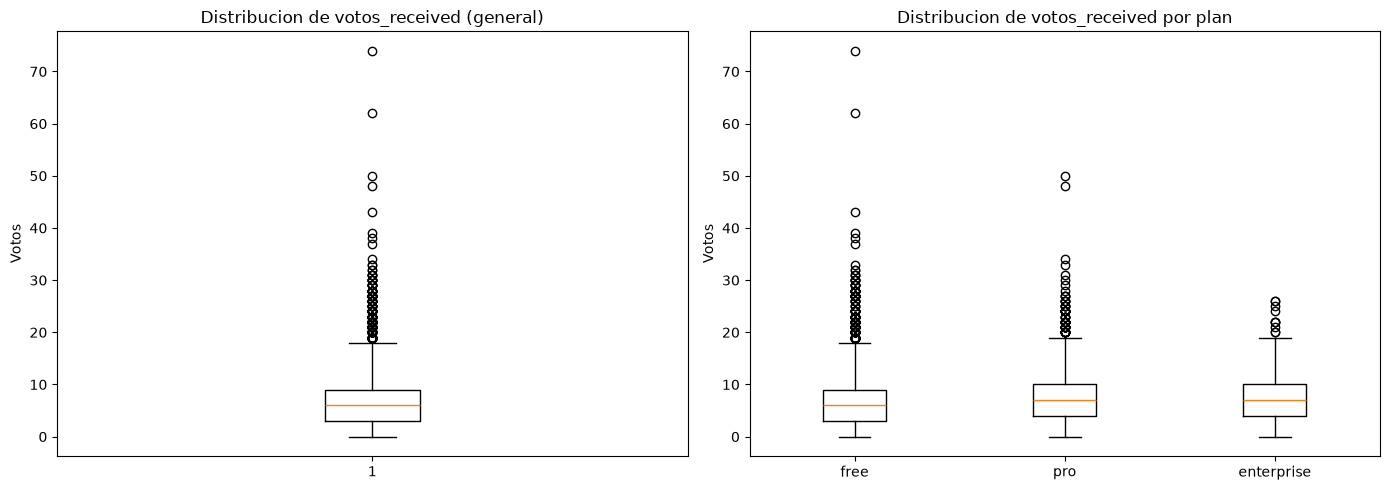

Media vs Mediana por plan (para comparar con el boxplot):
                mean  median
plan_type                   
enterprise  7.570571     7.0
free        6.692706     6.0
pro         7.654014     7.0


In [133]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot general
axes[0].boxplot(df_core['votes_received'], orientation='vertical')
axes[0].set_title('Distribucion de votos_received (general)')
axes[0].set_ylabel('Votos')

# Boxplot por plan (para comparar dispersion entre planes)
plan_order = ['free', 'pro', 'enterprise']
data_por_plan = [df_core[df_core['plan_type'] == p]['votes_received'] for p in plan_order]
axes[1].boxplot(data_por_plan, tick_labels=plan_order)
axes[1].set_title('Distribucion de votos_received por plan')
axes[1].set_ylabel('Votos')

plt.tight_layout()
plt.savefig('boxplot_votos.png', dpi=100)
plt.show()

print("Media vs Mediana por plan (para comparar con el boxplot):")
print(df_core.groupby('plan_type')['votes_received'].agg(['mean', 'median']))




Tendencia mensual:
            total_posts  votos_promedio  votos_totales
post_month                                            
2024-01             195        7.056410           1376
2024-02             370        7.040541           2605
2024-03             387        6.627907           2565
2024-04             394        6.979695           2750
2024-05             456        6.800439           3101
2024-06             389        6.776350           2636
2024-07             380        7.134211           2711
2024-08             388        6.703608           2601
2024-09             304        6.677632           2030
2024-10             353        7.237960           2555
2024-11             364        6.552198           2385
2024-12             374        6.791444           2540
2025-01             398        6.841709           2723
2025-02             299        7.096990           2122
2025-03             340        6.823529           2320
2025-04             382        6.717277      

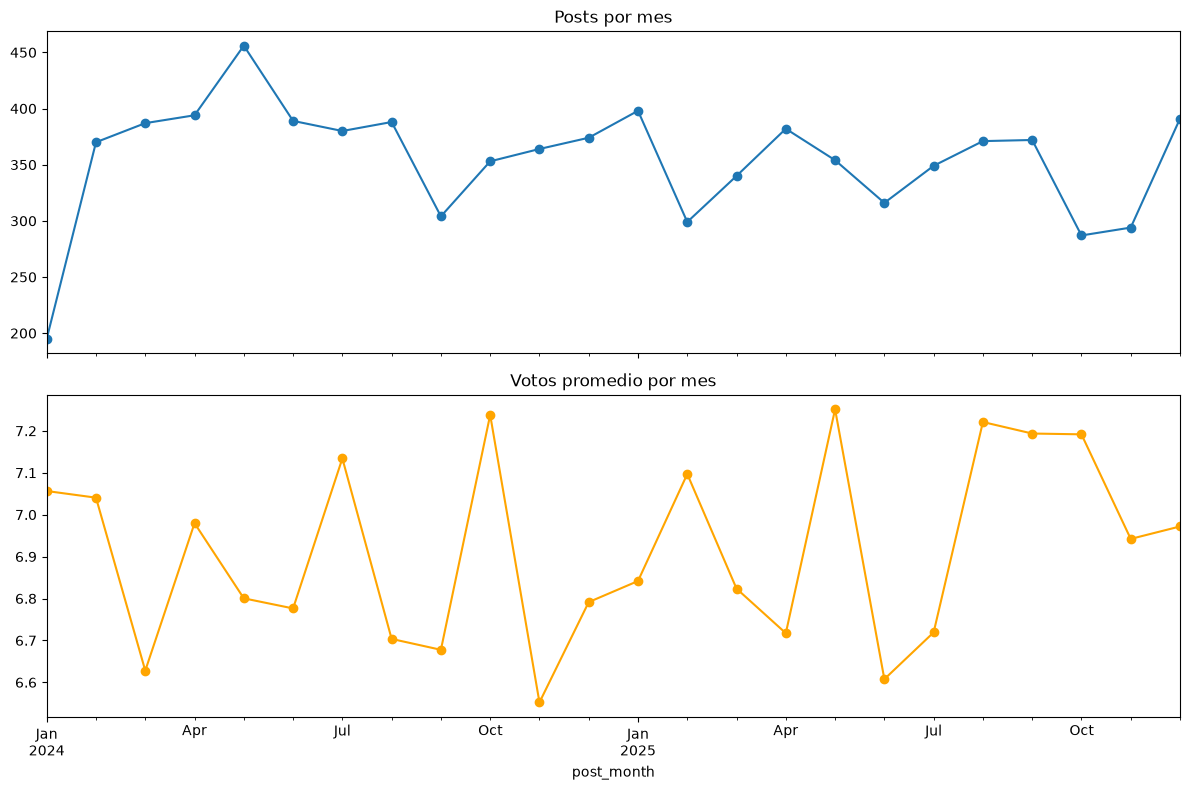

In [134]:
# Tendencia temporal (actividad y engagement por semana/mes)
df_core['post_month'] = df_core['post_created_at'].dt.to_period('M')
df_core['post_week'] = df_core['post_created_at'].dt.to_period('W')

tendencia_mensual = df_core.groupby('post_month').agg(
    total_posts=('post_id', 'count'),
    votos_promedio=('votes_received', 'mean'),
    votos_totales=('votes_received', 'sum')
)

print("\nTendencia mensual:")
print(tendencia_mensual)

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)
tendencia_mensual['total_posts'].plot(ax=axes[0], marker='o', title='Posts por mes')
tendencia_mensual['votos_promedio'].plot(ax=axes[1], marker='o', color='orange', title='Votos promedio por mes')

plt.tight_layout()
plt.savefig('tendencia_mensual.png', dpi=100)
plt.show()


Análisis de Cohortes por mes de signup
   cohort_month  usuarios_unicos  total_posts  votos_promedio  \
0       2024-01              106          538        7.096654   
1       2024-02               96          467        6.967880   
2       2024-03               91          408        6.553922   
3       2024-04               90          420        6.569048   
4       2024-05               93          446        6.899103   
5       2024-06               75          332        7.003012   
6       2024-07               80          301        7.186047   
7       2024-08               84          326        6.748466   
8       2024-09               75          362        6.798343   
9       2024-10               91          413        7.055690   
10      2024-11               72          266        6.665414   
11      2024-12               93          468        6.967949   
12      2025-01               80          370        6.610811   
13      2025-02               69          261     

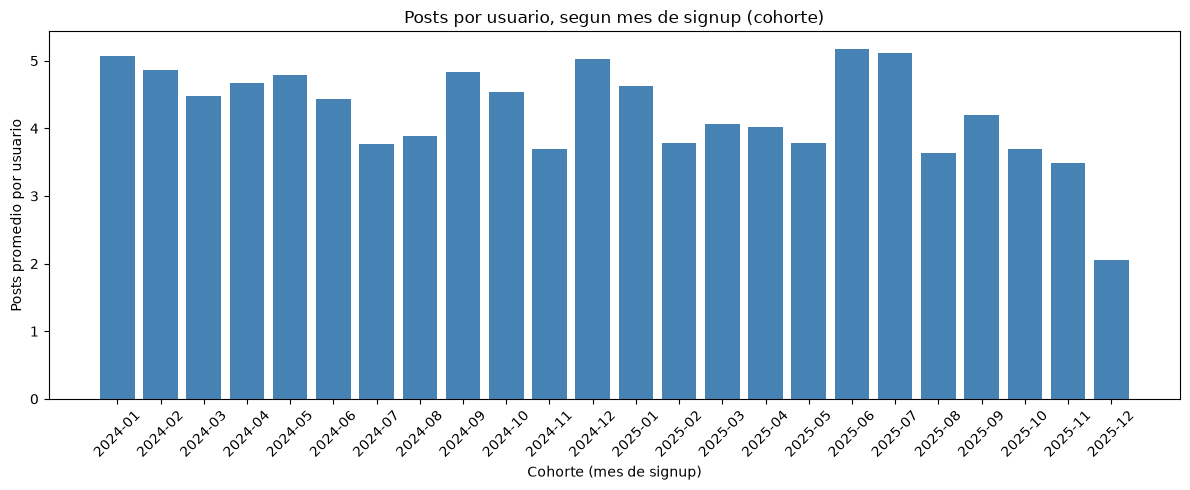

In [135]:
# Cohorte por mes
df_core['cohort_month'] = df_core['created_at'].dt.to_period('M')

cohortes = df_core.groupby('cohort_month').agg(
    usuarios_unicos=('user_id', 'nunique'),
    total_posts=('post_id', 'count'),
    votos_promedio=('votes_received', 'mean')
).reset_index()

cohortes['post_por_usuario'] = cohortes['total_posts'] / cohortes['usuarios_unicos']

print("\nAnálisis de Cohortes por mes de signup")
print(cohortes)

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(cohortes['cohort_month'].astype(str), cohortes['post_por_usuario'], color='steelblue')
ax.set_title("Posts por usuario, segun mes de signup (cohorte)")
ax.set_xlabel('Cohorte (mes de signup)')
ax.set_ylabel('Posts promedio por usuario')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cohortes_signup.png', dpi= 100)
plt.show()

In [136]:
# Verificación rápida antes de reportar el hallazgo de diciembre
print("Rango de fechas de post_created_at:", df_core['post_created_at'].min(), "a", df_core['post_created_at'].max())
print("\nCantidad de posts en diciembre 2025:", (df_core['post_month'] == '2025-12').sum())
print("Cantidad de posts en meses 'normales' (promedio):", tendencia_mensual['total_posts'].mean())

Rango de fechas de post_created_at: 2024-01-02 09:42:54 a 2025-12-31 23:59:59

Cantidad de posts en diciembre 2025: 391
Cantidad de posts en meses 'normales' (promedio): 354.4583333333333


## 6- Métrica propia - engagement_score

In [137]:
# 💡 Justificación: votes_received por sí solo no distingue entre
# "un post viral aislado" y "un usuario consistente". Un engagement_score
# combina el promedio (calidad) con el volumen (confiabilidad), penalizando
# a usuarios con muy pocos posts (su promedio es poco confiable).
resumen_usuario = df_core.groupby("user_id").agg(
    total_posts=('post_id', 'count'),
    votos_promedio=('votes_received','mean'),
    votos_totales=('votes_received','sum'),
    plan_type=('plan_type','first')
).reset_index()

# Fórmula: promedio de votos ponderado por confianza en el volumen
# (evita que 1 usuario con 1 post de 50 votos parezca "mejor" que uno con
# 30 posts a 8 votos promedio)
resumen_usuario['engagement_score'] = (
    resumen_usuario['votos_promedio'] * np.log1p(resumen_usuario['total_posts'])
)

print("Top 10 usuarios por engagement_score:")
print(resumen_usuario.sort_values('engagement_score', ascending=False).head(10))

Top 10 usuarios por engagement_score:
     user_id  total_posts  votos_promedio  votos_totales plan_type  \
1217  U01223           15       12.533333            188      free   
1449  U01456            2       28.500000             57       pro   
879   U00885           35        8.685714            304       pro   
1002  U01008           25        8.680000            217       pro   
1760  U01767           13       10.538462            137      free   
1608  U01615            8       12.500000            100      free   
897   U00903            4       17.000000             68      free   
961   U00967           38        7.368421            280      free   
1860  U01868            4       16.750000             67      free   
1973  U01981           16        9.375000            150       pro   

      engagement_score  
1217         34.749779  
1449         31.310450  
879          31.125422  
1002         28.280278  
1760         27.811604  
1608         27.465307  
897          27.

In [138]:
# metrics_summary.csv
metrics_summary = pd.DataFrame([
    {'metric': 'filas_raw', 'value': len(df_raw)},
    {'metric': 'filas_core', 'value': len(df_core)},
    {'metric': 'filas_quarantine', 'value': len(df_quarantine)},
    {'metric': 'pct_quarantine', 'value': round(len(df_quarantine)/len(df_raw)*100, 2)},
    {'metric': 'votos_promedio_evento', 'value': round(df_core['votes_received'].mean(), 2)},
    {'metric': 'votos_promedio_usuario', 'value': round(votos_promedio_usuario, 2)},
    {'metric': 'pct_votos_top1pct_usuarios', 'value': 6.43},
    {'metric': 'pct_votos_top20pct_usuarios', 'value': 51.92},
    {'metric': 'usuarios_unicos', 'value': n_usuarios},
    {'metric': 'posts_por_usuario_mediana', 'value': post_por_usuario.median()},
])
metrics_summary.to_csv('metrics_summary.csv', index=False)
print(metrics_summary)

                        metric    value
0                    filas_raw  8782.00
1                   filas_core  8507.00
2             filas_quarantine   275.00
3               pct_quarantine     3.13
4        votos_promedio_evento     6.91
5       votos_promedio_usuario     6.90
6   pct_votos_top1pct_usuarios     6.43
7  pct_votos_top20pct_usuarios    51.92
8              usuarios_unicos  1994.00
9    posts_por_usuario_mediana     3.00


In [139]:
df_core.to_csv('clean_product_activity.csv', index=False)
df_quarantine.to_csv('quarantine_product_activity.csv', index=False)

print("\n✅ Archivos exportados: clean_product_activity.csv, quarantine_product_activity.csv, metrics_summary.csv")


✅ Archivos exportados: clean_product_activity.csv, quarantine_product_activity.csv, metrics_summary.csv
